# **Laboratorio 14: Extracción de Características**

Departamento de Ingeniería Biomédica

Universidad de los Andes

**IBIO-2340:** Fundamentos de Machine Learning

 **Nombres de los integrantes**


1.   Nombre integrante 1
2.   Nombre integrante 2
3.   Nombre integrante 3

**Número del grupo**

*Escribir el número del grupo*

# **Contexto del problema**

La Lengua de Señas Colombiana (LSC) es un sistema lingüístico viso-gestual que depende de la configuración de las manos, su orientación y posición espacial. En el caso de señas estáticas, la información relevante se encuentra contenida en una sola imagen o *frame*, lo que permite abordar el problema como una tarea de clasificación supervisada.

En este laboratorio vamos a desarrollar un *pipeline* completo para la clasificación de $11$ señas estáticas de LSC utilizando:

- El modelo HandLandmaker de **Google MediaPipe** para la extracción de características anatómicas de la mano durante la ejecución de la seña.

- Una red neuronal entrenada sobre estas características para identificar cada seña.

### **Visualización del conjunto de datos**

En primer lugar importamos las librerias de trabajo y mostramos la información contenida en la base de datos:

In [ ]:
# Si usas Google Colab, descomenta esta celda y ejecutala para descomprimir las carpetas
# !unzip -q LSC_dataset.zip
# !unzip -q models.zip


In [1]:
# Librerias de uso general
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Extracción de características
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Modelos de Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos de Deep Learning
import tensorflow as tf
from tensorflow import keras

In [2]:
# Parámetros globales de la imagen

# Reducimos el número de pixeles para reducir el consumo de memoria
# No es crítico porque los detalles a capturar no son locales, sino generales
IMG_SIZE = 200 

# Imagen RGB
IMG_CHANNEL = 3 

# Diccionario para mapear clases y etiquetas
CLASS_LABEL_DICT = {}

# Configuración general de la tarea
N_CLASSES = 0

LSC_dataset\1\hand1_1_bot_seg_1_cropped.jpeg
LSC_dataset\2\hand1_2_bot_seg_1_cropped.jpeg
LSC_dataset\4\hand1_4_bot_seg_1_cropped.jpeg
LSC_dataset\5\hand1_5_bot_seg_1_cropped.jpeg
LSC_dataset\b\hand1_b_bot_seg_1_cropped.jpeg
LSC_dataset\i\hand1_i_bot_seg_1_cropped.jpeg
LSC_dataset\l\hand1_l_bot_seg_1_cropped.jpeg
LSC_dataset\r\hand1_r_bot_seg_1_cropped.jpeg
LSC_dataset\v\hand1_v_bot_seg_2_cropped.jpeg
LSC_dataset\w\hand1_w_bot_seg_1_cropped.jpeg
LSC_dataset\y\hand1_y_bot_seg_1_cropped.jpeg


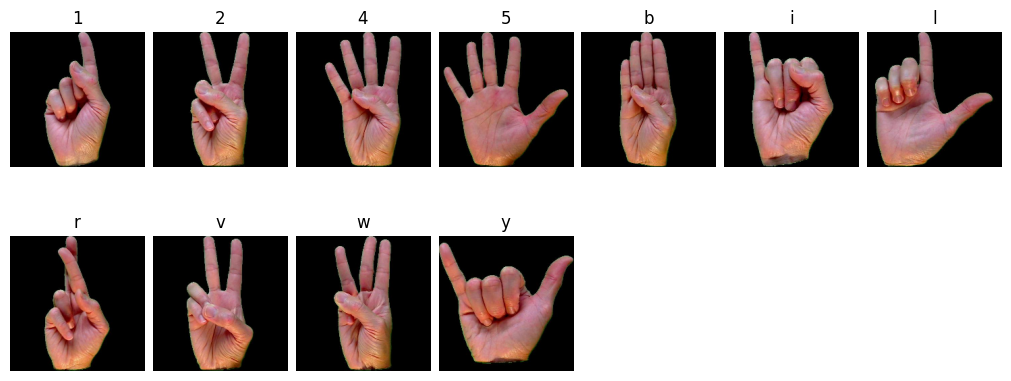

In [ ]:
#Visualizamos una imagen de cada categoria en el conjunto de datos
data_dir = "LSC_dataset"
lsc_categories = sorted(os.listdir(data_dir))

# Se confirma el número de clases con la información del conjunto de satos
N_CLASSES = len(lsc_categories)

# Configuramos el grafico usando matplotlib, agregando los ejes de forma dinámica
fig = plt.figure(figsize=(10,8), layout="constrained") # Ancho x alto
# Cantidad de columnas a agregar
columns_figure = int(N_CLASSES/3)+1

# Aprovechamos el ciclo para contar el número de imagenes de cada clase
image_class_count = {}

for index, category in enumerate(lsc_categories):
   folder_category = os.path.join(data_dir, category)
   
   # Contamos el número total de imágenes y usamos el nombre de la clase como llave
   image_class_count[category] = len(os.listdir(folder_category))

   # Recuperamos la primera imagen de cada categoria
   image_file = os.listdir(folder_category)[0] 
   img_path = os.path.join(folder_category, image_file)
   img = keras.preprocessing.image.load_img(img_path, target_size=(IMG_SIZE,IMG_SIZE)) # Se reduce la resolución, se interpolan los píxeles 
   ax = fig.add_subplot(columns_figure,7, index+1) # add_subplots se indexa desde 1 (a diferencia de subplots())
   ax.set_axis_off()
   ax.imshow(img)
   ax.set_title(category)

plt.show()

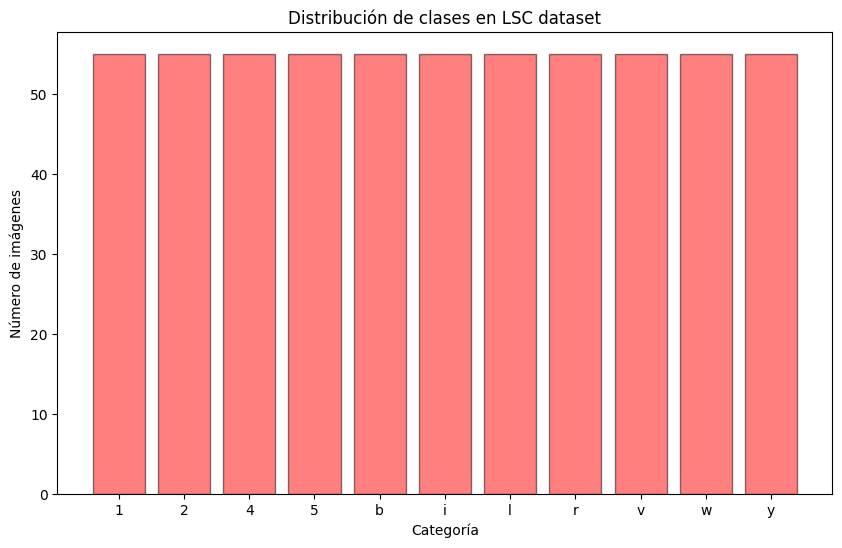

In [4]:
# Hacemos un gráfico de barras con la frecuencia de cada clase en el conjunto de datos
fig, ax = plt.subplots(figsize=(10,6))
ax.bar(x=image_class_count.keys(), height=image_class_count.values(), color='red', edgecolor='black', alpha=0.5)
ax.set_title("Distribución de clases en LSC dataset")
ax.set_ylabel("Número de imágenes")
ax.set_xlabel("Categoría")
plt.show()

### **Extracción de Características**

Utilizamos el modelo <*HandLandmarker*> de la libreria *MediaPipe*, el cual permite detectar 21 puntos anatómicos de la mano, tanto en la palma como en el dorso. Cada punto se identifica mediante un triplete de coordenadas $(x,y,z)$ que pueden expresarse en coordenadas relativas ("*Landmarks*") o globales ("*WorldLandmarks*"), y con su lateralidad (detectado en la mano *izquierda* o *derecha*).

El entrenamiento del modelo se realizo con aproximadamente $30000$ imágenes de manos reales, complementadas con múltiples manos sintéticas renderizadas sobre diversos fondos. Asimismo, permite realizar detección en imágenes estáticas, videos y capturas en tiempo real.



<div style="text-align: center;">
    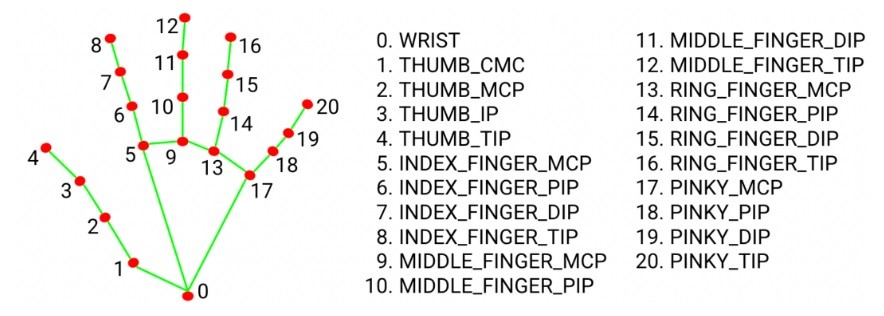
    <p>Posiciones anatómicas de la mano identificadas por HandLandmarker de Google MediaPipe</p>
</div>

En nuestro caso, cada seña se caracteriza a partir de las coordenadas $(x,y)$ de los $21$ *Landmarks* detectados, trasladando el origen de coordenadas a la muñeca (*Landmark* $0$). Esta trasformación garantiza la invarianza del sistema frente a traslaciones y rotaciones de la mano.

La función `FeatureExtraction_Sign()` recupera los $21$ *landmarks* detectados, aplica la transformación de coordenadas descrita y retorna dos arreglos: el primero contiene las características extraídas (coordenadas $(x,y)$ con respecto al nuevo origen), mientras el segundo almacena las etiquetas asociadas a cada seña. 

In [5]:
def FeatureExtraction_Sign(path_set:str):
    features_set = [] # Arreglo que contiene las coordenadas de los landmarks de cada mano
    labels_set = [] # Contiene la etiqueta {1,2,3,..} asociada a cada categoria

    # Creamos el objeto HandLandMarker (ver https://ai.google.dev/edge/mediapipe/solutions/vision/hand_landmarker/index?hl=es-419#models)
    # Descargamos el archivo que contiene la configuración del modelo
    base_options = python.BaseOptions(model_asset_path='models/hand_landmarker.task')
    # Debemos especificar que las imágenes contienen una sola mano. Por defecto toma como inputs imágenes
    options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1, min_hand_detection_confidence=0.2, min_hand_presence_confidence=0.2, min_tracking_confidence=0.2,) 
    # Generamos la instancia del modelo con la configuración establecida
    detector = vision.HandLandmarker.create_from_options(options)

    for label, class_name in enumerate(os.listdir(path_set)):
        class_path = os.path.join(path_set, class_name)
        # Diccionario de mapeo clase y etiqueta 
        CLASS_LABEL_DICT[label] = class_name

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)
            # Cargamos la imagen en el formato de mediapipe
            image = mp.Image.create_from_file(image_path)

            # Detección de landmarks
            result_extraction = detector.detect(image)

            if result_extraction.hand_landmarks:
                # Recuperamos directamente los landmarks (lista con los datos de cada mano, en este caso solo utilizamos una)
                landmarks = result_extraction.hand_landmarks[0]

                # Creamos un arreglo que contiene las coordenadas X,Y de cada landmark extraido de tamaño (21,2)
                # una fila por cada landmark (punto de referencia, se extraen 21), una columna para cada coordenada
                features = np.array(
                    [[lm.x, lm.y] for lm in landmarks]
                )

                # Para garantizar la invarianza ante rotaciones de la imagen, trasladamos el sistema de coordenadas de mediapipe
                # para tomar como punto de referencia a la posición de la muñeca en cada seña (landmark 0)
                features = features - features[0,:] # Aprovechamos el broadcasting de Numpy

                # Aplanamos el arreglo, de modo que se intercalan las coordenadas x,y por landmark
                # Formato necesario para que actúe como entrada del modelo. Tamaño (42,)
                features = features.flatten()

                # Agregamos las características de la seña y la etiqueta de la clase a los conjunto de datos
                features_set.append(features)
                labels_set.append(label)
            else:
                # Removemos las imágenes en las que el detector no puede inferir ninguna posición
                print("Eliminando...")
                os.remove(image_path)
       
    return np.array(features_set), np.array(labels_set)

### **Preparación del conjunto de datos**

Extraemos las características del conjunto de datos y preparamos los conjuntos de entrenamiento ($70\%$), validación ($20\%$) y prueba ($10\%$):

In [6]:
# Características a considerar para el modelo
X_features, y_features = FeatureExtraction_Sign(data_dir)
print(f"Tamaño del conjunto: X: {X_features.shape}, y: {y_features.shape}")

Tamaño del conjunto: X: (605, 42), y: (605,)


In [7]:
# Tamaño de los conjuntos de prueba y validación
test_size = 0.1
val_size = 0.2

# Separamos el conjunto de datos inicial en un conjunto temporal (entrenamiento y validación) y el conjunto de prueba
X_temp, X_test, y_temp, y_test = train_test_split(X_features,y_features,test_size=test_size, random_state=42, stratify=y_features)

# Calculamos el porcentaje de validación ajustado a la separación inicial
val_size = val_size/(1 - test_size)

# Separamos el conjunto temporal en entrenamiento y validación, con el porcentaje ajustado
X_train, X_val, y_train, y_val = train_test_split(X_temp,y_temp,test_size=val_size, random_state=42, stratify=y_temp)
print(f"Tamaño del conjunto de entrenamiento: X: {X_train.shape}, y: {y_train.shape}")
print(f"Tamaño del conjunto de validación: X: {X_val.shape}, y: {y_val.shape}")
print(f"Tamaño del conjunto de prueba: X: {X_test.shape}, y: {y_test.shape}")

Tamaño del conjunto de entrenamiento: X: (423, 42), y: (423,)
Tamaño del conjunto de validación: X: (121, 42), y: (121,)
Tamaño del conjunto de prueba: X: (61, 42), y: (61,)


Observe que en este caso, el modelo impone una separación lineal en el espacio de representación y actúa de forma similar al modelo de Regresión Logística, por lo que no puede clasificar con buena precisión los datos.

# **Ejercicios**

**1.** Implemente un modelo de MLP con una capa oculta de 25 neuronas utilizando *ReLu* como función de activación en los datos de entrenamiento. Considere un *batch* de $32$, $100$ épocas y *adam* como optimizador.

**2.** Grafique la curva de aprendizaje del modelo anterior utilizando *loss* como métrica. Incluya la matriz de confusión e imprima el *classification report* para los datos en el conjunto de validación.  

*Hint:* Utilice la función `classification_report()` de la libreria *Scikit-Learn*.

**3.** Entrene un modelo de Regresión Logística con un número máximo de iteraciones de $5000$ y una constante de regularización $C$ de $50$.

**4.** Grafique la curva de aprendizaje del modelo anterior utilizando *recall_macro* como métrica. Incluya la matriz de confusión  e imprima el *classification report* para los datos en el conjunto de validación.

*Hint:* Utilice la función `learning_curve()` de la libreria *Scikit-Learn* con $5$ folds y *train_sizes* de $10$ puntos entre $0.1$ y $1.0$. Recuerde que no es necesario distinguir entre *train* y *validation*, en este caso use los conjuntos *X_temp* y *y_temp*.

**5.**  Elija 6 dígitos al azar del conjunto de prueba, especifique su etiqueta y añada un gráfico de barras con las probabilidades de pertenencia de cada clase generada por los dos modelos.

**6.** Finalmente, analice y compare los reportes de clasificación, la matriz de confusión y la distribución de probabilidad de ambos modelos. ¿Qué puede concluir de esta comparación? Justifique cúal de los dos modelos es el más apropiado para resolver la tarea en cuestión.